# UCI Heart Disease Classification
UCI Heart Disease
https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data  
Random Forest, XGBoost
Predict presence of heart disease (`target`: 0 = no disease, 1 = disease)

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_recall_curve
)
from sklearn.impute import SimpleImputer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [29]:
df = pd.read_csv('heart_disease_uci 2.csv')
print(df.dtypes)
df.head()

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [30]:
# Binarize target: 0 = no disease, 1 = any disease (num 1-4)
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num', 'id', 'dataset'])

# categorical columns
categorical = ['cp', 'restecg', 'slope', 'thal', 'sex', 'fbs', 'exang']

print('Missing values per column:')
print(df.isnull().sum())

disease = (df['target'] == 1).sum()
healthy = (df['target'] == 0).sum()
print(f"\nHeart Disease (1): {disease:,}")
print(f"Healthy       (0): {healthy:,}")

Missing values per column:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Heart Disease (1): 509
Healthy       (0): 411


In [69]:
# mapping strings to numerical veriables
slope_num = df['slope'].map({'upsloping': 1, 'flat': 2, 'downsloping': 3}).fillna(1)
exang_num = df['exang'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0)

# heart-rate reserve: dfiference between expected (by age) and actual heart rate
# 220 is used in maximum heart rate formula
df['hr_reserve'] = (220 - df['age']) - df['thalch']

# ratio between actual and expected heart rate
df['hr_ratio'] = df['thalch'] / (220 - df['age'])

# ST depression, weighted by slope severity
df['st_severity'] = df['oldpeak'].fillna(0) * slope_num

# Clinical threshold flags
df['high_chol'] = (df['chol'] > 200).astype(int)
df['hypertension'] = (df['trestbps'] > 140).astype(int)

# Age x exercise angina interaction (determines severity of angina depending on age)
df['age_angina'] = df['age'] * exang_num

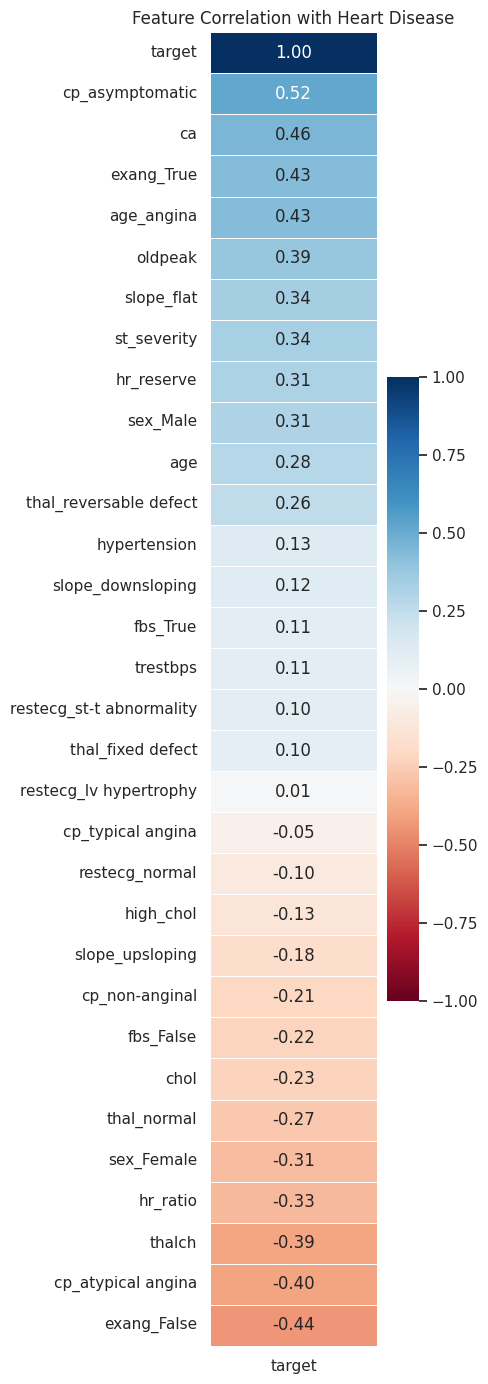

In [70]:
#temporarily encoding for this view
df_enc = pd.get_dummies(df, columns=categorical, drop_first=False)
df_enc = df_enc.apply(pd.to_numeric, errors='coerce')

corr_target = (
    df_enc.corr(numeric_only=True)[['target']]
    .sort_values('target', ascending=False)
)

plt.figure(figsize=(5, 14))
sns.heatmap(corr_target, annot=True, fmt='.2f', cmap='RdBu',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation with Heart Disease')
plt.tight_layout()
plt.show()

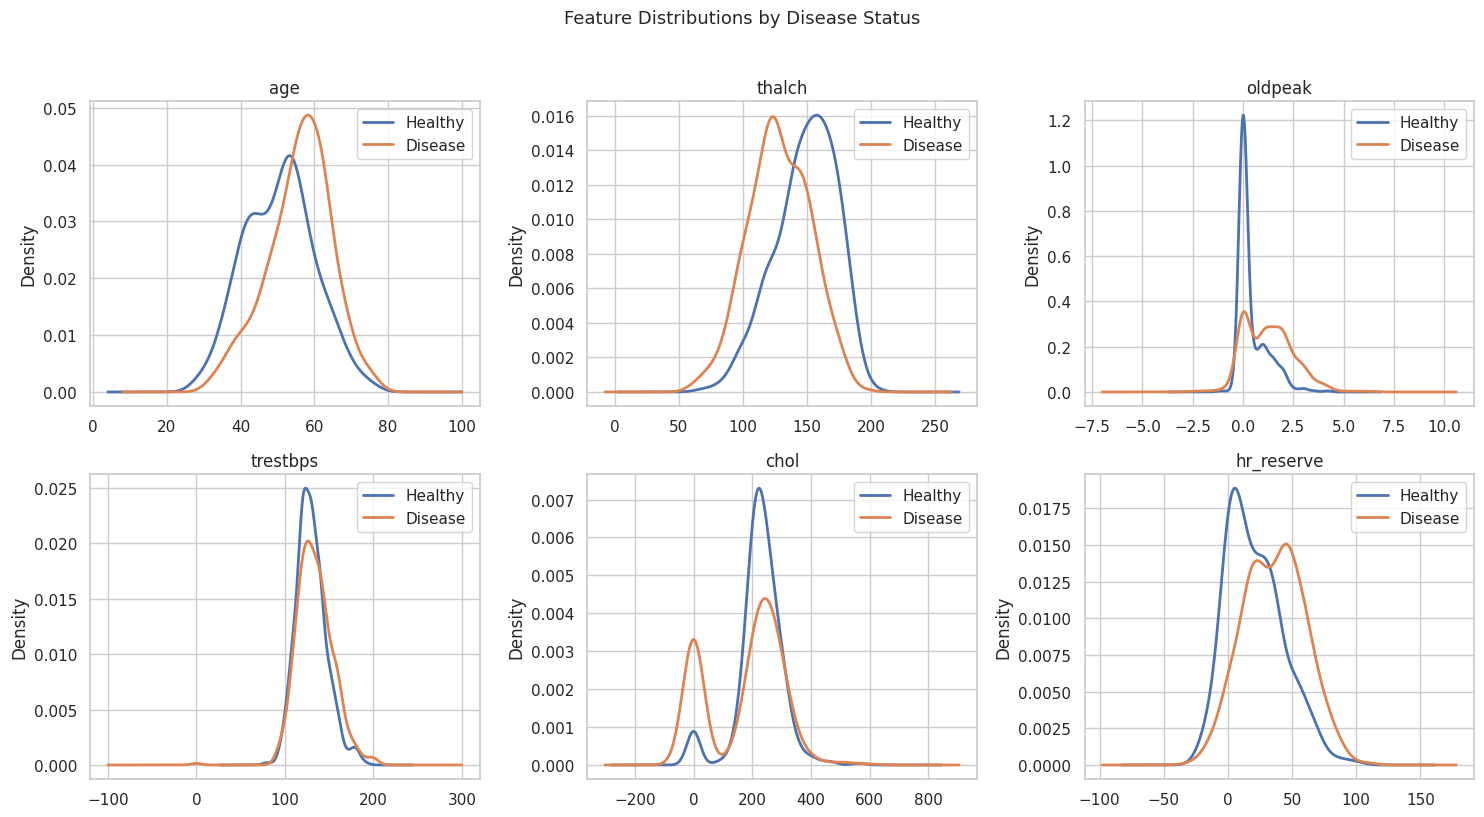

In [71]:
cont_features = ['age', 'thalch', 'oldpeak', 'trestbps', 'chol', 'hr_reserve']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, cont_features):
    for label, grp in df.groupby('target'):
        grp[feat].dropna().plot.kde(
            ax=ax, label='Healthy' if label == 0 else 'Disease', lw=2
        )
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Disease Status', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [72]:
label = 'target'

X = df.drop(columns=[label]).copy()
y = df[label].copy()

non_dropped_categoricals = [c for c in categorical if c in X.columns]
X = pd.get_dummies(X, columns=non_dropped_categoricals, drop_first=False)
X = X.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print('Features used:', list(X_imp.columns))
print(f'X shape: {X_imp.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')#

Features used: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'hr_reserve', 'hr_ratio', 'st_severity', 'high_chol', 'hypertension', 'age_angina', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect', 'sex_Female', 'sex_Male', 'fbs_False', 'fbs_True', 'exang_False', 'exang_True']
X shape: (920, 31)
Train: 736 rows | Test: 184 rows


In [79]:
rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)
y_prob_rf  = rf_base.predict_proba(X_test)[:, 1]

cv_auc_rf = cross_val_score(
    rf_base, X_imp, y, cv=cv, scoring='roc_auc', n_jobs=-1
).mean()

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Heart Disease']))
print(f'Test  ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'10-fold CV AUC: {cv_auc_rf:.4f}')

=== Random Forest ===
               precision    recall  f1-score   support

      Healthy       0.86      0.82      0.84        82
Heart Disease       0.86      0.89      0.88       102

     accuracy                           0.86       184
    macro avg       0.86      0.85      0.86       184
 weighted avg       0.86      0.86      0.86       184

Test  ROC-AUC : 0.9297
10-fold CV AUC: 0.8931


In [80]:
from tqdm.notebook import tqdm
import random

random.seed(42)
candidates = [
    {
        'n_estimators':     random.randint(100, 600),
        'max_depth':        random.randint(3, 5),
        'learning_rate':    random.uniform(0.01, 0.20),
        'subsample':        random.uniform(0.7, 1.0),
        'colsample_bytree': random.uniform(0.7, 1.0),
        'min_child_weight': random.randint(1, 5),
        'gamma':            random.uniform(0, 0.3),
        'reg_alpha':        random.uniform(0, 0.2),
        'reg_lambda':       random.uniform(1.0, 2.0),
    }
    for _ in range(50)
]

best_score, best_params = 0, None

for params in tqdm(candidates, desc='XGBoost Search', unit='candidate'):
    m = xgb.XGBClassifier(
        **params,
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )
    auc = cross_val_score(
        m, X_train_sc, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    ).mean()
    if auc > best_score:
        best_score, best_params = auc, params

print(f'Best CV ROC-AUC : {best_score:.4f}')
print(f'Best Params     : {best_params}')

# Fit best model on full training set for use in remaining cells
best_xgb = xgb.XGBClassifier(
    **best_params,
    tree_method='hist',
    device='cuda',
    eval_metric='logloss',
    random_state=RANDOM_STATE
)
best_xgb.fit(X_train_sc, y_train)
y_pred_xgb = best_xgb.predict(X_test_sc)
y_prob_xgb = best_xgb.predict_proba(X_test_sc)[:, 1]

XGBoost Search:   0%|          | 0/50 [00:00<?, ?candidate/s]

Best CV ROC-AUC : 0.8866
Best Params     : {'n_estimators': 316, 'max_depth': 3, 'learning_rate': 0.015661471693233366, 'subsample': 0.765591392441081, 'colsample_bytree': 0.8516065864310087, 'min_child_weight': 1, 'gamma': 0.1683735188815839, 'reg_alpha': 0.1432039225844807, 'reg_lambda': 1.701324973590236}


In [55]:
y_pred_xgb = best_xgb.predict(X_test_sc)
y_prob_xgb = best_xgb.predict_proba(X_test_sc)[:, 1]

print("=== XGBoost (tuned) ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Healthy', 'Heart Disease']))
print(f"Test ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost (tuned) ===
               precision    recall  f1-score   support

      Healthy       0.88      0.80      0.84        82
Heart Disease       0.85      0.91      0.88       102

     accuracy                           0.86       184
    macro avg       0.87      0.86      0.86       184
 weighted avg       0.87      0.86      0.86       184

Test ROC-AUC : 0.9249


── Default threshold (0.50) ──
               precision    recall  f1-score   support

      Healthy       0.88      0.80      0.84        82
Heart Disease       0.85      0.91      0.88       102

     accuracy                           0.86       184
    macro avg       0.87      0.86      0.86       184
 weighted avg       0.87      0.86      0.86       184

── Optimal threshold (0.498) ──
               precision    recall  f1-score   support

      Healthy       0.89      0.80      0.85        82
Heart Disease       0.85      0.92      0.89       102

     accuracy                           0.87       184
    macro avg       0.87      0.86      0.87       184
 weighted avg       0.87      0.87      0.87       184



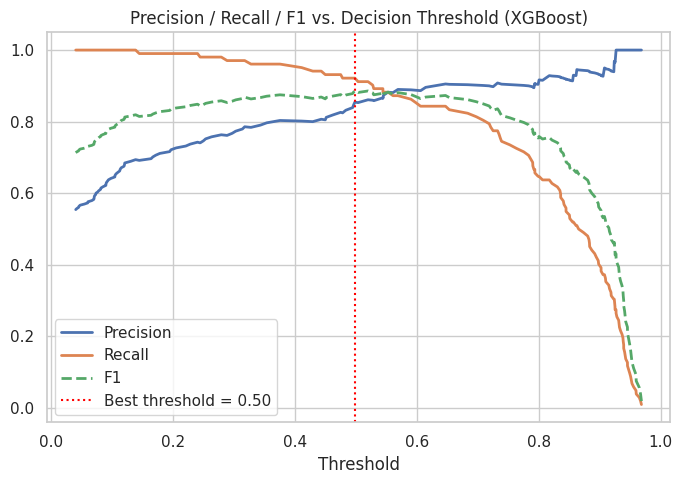

In [56]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores   = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]

print('── Default threshold (0.50) ──')
print(classification_report(
    y_test, (y_prob_xgb >= 0.50).astype(int),
    target_names=['Healthy', 'Heart Disease']
))
print(f'── Optimal threshold ({best_thresh:.3f}) ──')
print(classification_report(
    y_test, (y_prob_xgb >= best_thresh).astype(int),
    target_names=['Healthy', 'Heart Disease']
))

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label='Precision', lw=2)
plt.plot(thresholds, recall[:-1],    label='Recall',    lw=2)
plt.plot(thresholds, f1_scores[:-1], label='F1',        lw=2, linestyle='--')
plt.axvline(best_thresh, color='red', linestyle=':',
            label=f'Best threshold = {best_thresh:.2f}')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs. Decision Threshold (XGBoost)')
plt.legend()
plt.tight_layout()
plt.show()

RF Grid:   0%|          | 0/20 [00:00<?, ?model/s]

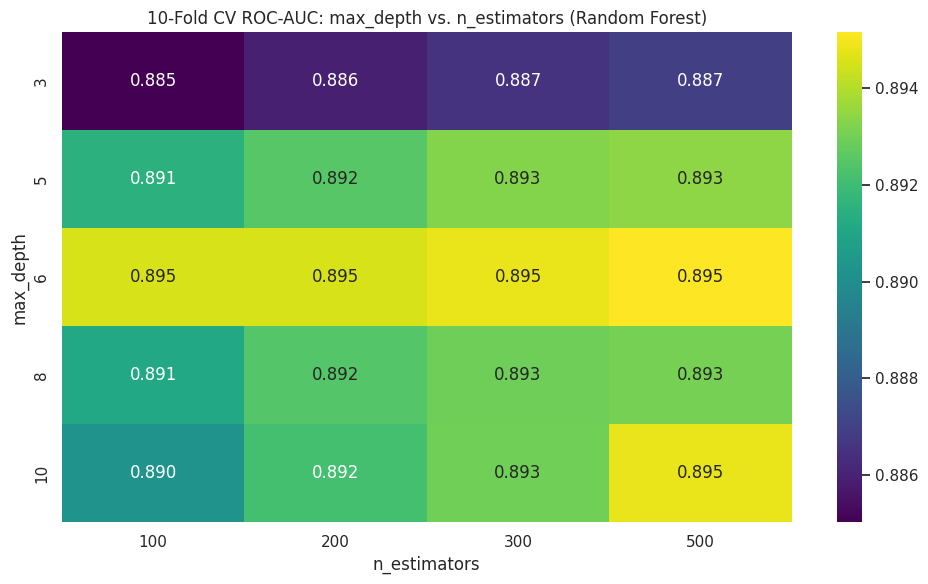

In [59]:
n_estimators_range = [100, 200, 300, 500]
depth_range        = [3, 5, 6, 8, 10]
total              = len(depth_range) * len(n_estimators_range)
scores             = np.zeros((len(depth_range), len(n_estimators_range)))

with tqdm(total=total, desc='RF Grid', unit='model') as pbar:
    for i, depth in enumerate(depth_range):
        for j, n in enumerate(n_estimators_range):
            m = RandomForestClassifier(
                n_estimators=n, max_depth=depth,
                min_samples_leaf=3, class_weight='balanced',
                random_state=RANDOM_STATE, n_jobs=-1
            )
            scores[i, j] = cross_val_score(
                m, X_imp, y, cv=cv, scoring='roc_auc', n_jobs=-1
            ).mean()
            pbar.set_postfix(depth=depth, n=n, auc=f'{scores[i,j]:.3f}')
            pbar.update(1)

plt.figure(figsize=(10, 6))
sns.heatmap(scores, annot=True, fmt='.3f',
            xticklabels=n_estimators_range,
            yticklabels=depth_range, cmap='viridis')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.title('10-Fold CV ROC-AUC: max_depth vs. n_estimators (Random Forest)')
plt.tight_layout()
plt.show()

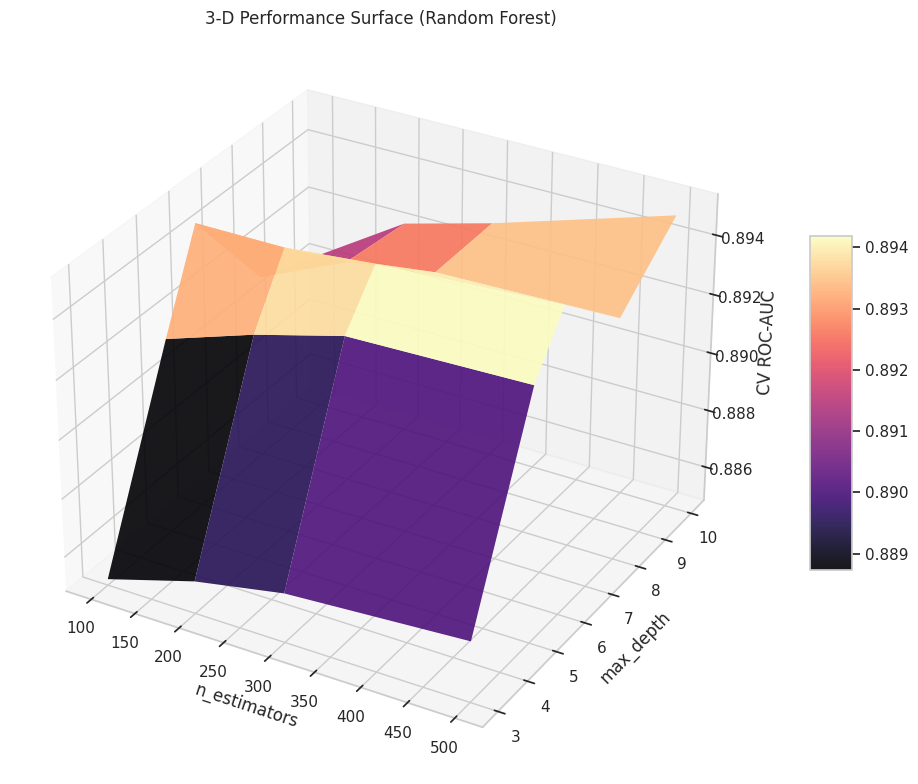

In [60]:
X_mesh, Y_mesh = np.meshgrid(n_estimators_range, depth_range)
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X_mesh, Y_mesh, scores, cmap='magma', edgecolor='none', alpha=0.9)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('CV ROC-AUC')
ax.set_title('3-D Performance Surface (Random Forest)')
fig.colorbar(surf, ax=ax, shrink=0.45, aspect=8)
plt.tight_layout()
plt.show()

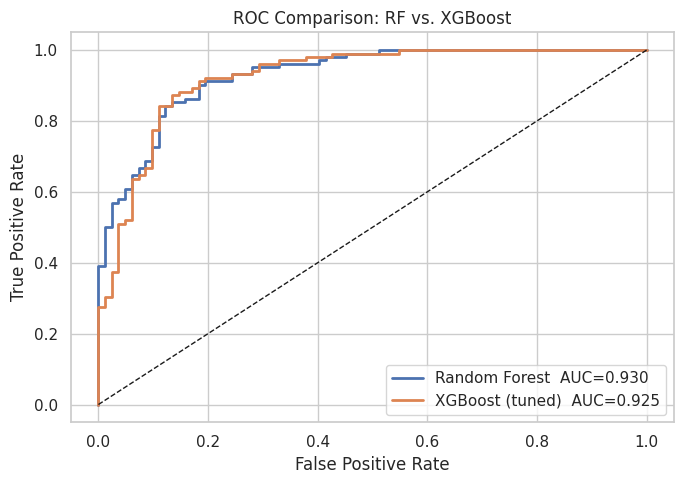

In [62]:
plt.figure(figsize=(7, 5))
for name, y_prob in [
    ('Random Forest',   y_prob_rf),
    ('XGBoost (tuned)', y_prob_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name}  AUC={roc_auc_score(y_test, y_prob):.3f}')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison: RF vs. XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

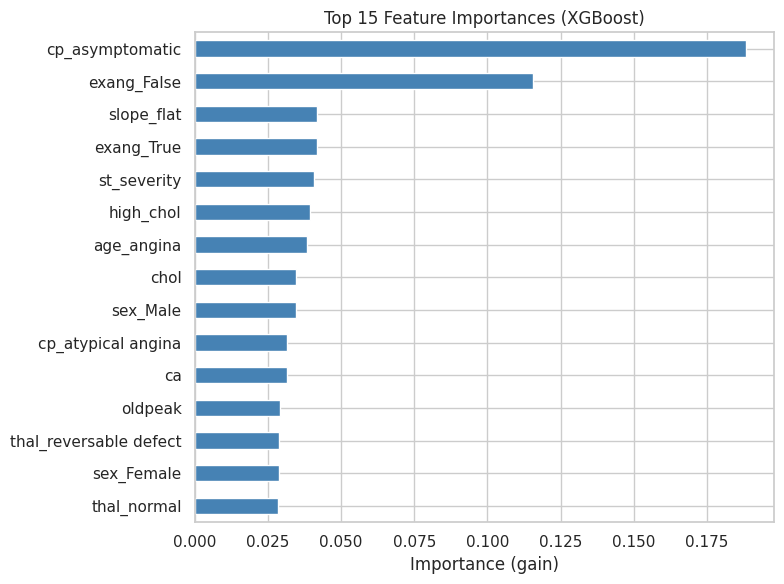

In [63]:
importances = pd.Series(best_xgb.feature_importances_, index=X_imp.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Importance (gain)')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

In [64]:
results = pd.DataFrame([
    {'Model': 'Random Forest', 'Test AUC': roc_auc_score(y_test, y_prob_rf), '10-fold CV AUC': cv_auc_rf},
    {'Model': 'XGBoost (tuned)', 'Test AUC': roc_auc_score(y_test, y_prob_xgb), '10-fold CV AUC': best_score},
]).set_index('Model')

print(results.round(4).to_string())

                 Test AUC  10-fold CV AUC
Model                                    
Random Forest      0.9297          0.8931
XGBoost (tuned)    0.9249          0.8866


# Summary


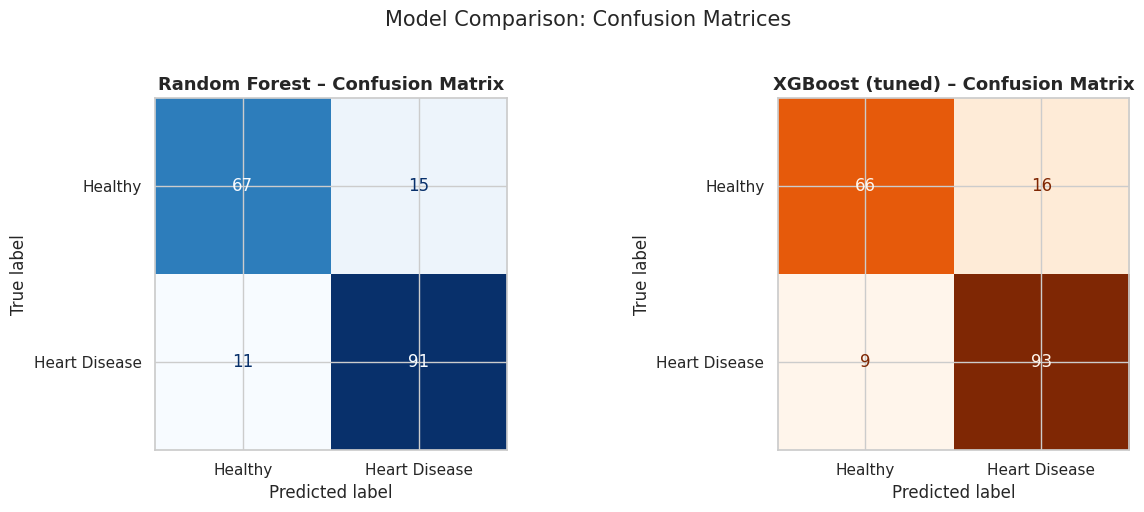

In [67]:
#summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest – Confusion Matrix', fontsize=13, fontweight='bold')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('XGBoost (tuned) – Confusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Model Comparison: Confusion Matrices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()